In [41]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [42]:
import warnings
warnings.filterwarnings("ignore")

import math
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as PipelineImb
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBClassifier
    xgboost_disponible = True
    print("XGBoost importé avec succès.")
except Exception as e:
    xgboost_disponible = False
    print("XGBoost indisponible :", e)


XGBoost importé avec succès.


## ETAPE 1: COMPREHENSION METIER

**OBJECTIF PRINCIPAL :** Une banque a mené des campagnes téléphoniques pour convaincre ses clients de souscrire à un dépôt à terme. Notre objectif est de construire un modèle capable de prédire si un client va souscrire (**yes**) ou non (**no**).

**OBJECTIF METIER :** La banque veut utiliser les données des anciennes campagnes pour sélectionner les clients à cibler et les contacter par ordre de priorité, afin d’augmenter les souscriptions tout en limitant les coûts. On garde donc une approche relativement équilibrée.

**1.1. Quelle est la variable cible?**
   -  Notre Variable cible est **y**
       - La variable cible **y** indique si un client a souscrit à un dépôt à terme (**yes** ou **no**)
   - L'intérêt métier : mieux cibler les clients susceptibles d'accepter l'offre, nous permettant ainsi de limiter les coûts. 
   

**1.2- A quel type de probleme avons-nous a faire**: 
   - C'est un problème de **classification binaire** car on predit une variable à 2 catégories: **yes**/**no**
   

**1.3- Que représente la campagne marketing?**
   - Chaque ligne de nos données represente un appel téléphonique. La banque a donc appelé 41188 clients pour leur proposer l'offre.
   - un **yes** ou **no** dans la variable cible signifie:
      - **yes** : le client a **accepté** l'offre
      - **no** : le client a **réfusé** l'offre

## ETAPE 2: COMPREHENSION DES DONNEES

Notre objectif ici sera de trouver les problemes liés aux données à savoir s'il y'a des données manquantes, des valeurs aberrantes et mieux connaitre les differentes variables

**Chargement des données**

In [2]:
CHEMIN_FICHIER = "C:\\Users\\Utilisateur\\Documents\\M2_MIAGE_2025-2026\\Fouilles De Données\\bank+marketing\\bank-additional\\bank-additional\\bank-additional-full.csv"

Cestia = pd.read_csv(CHEMIN_FICHIER,sep=';')
Cestia.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**2.1- la taille du dataset?**

In [3]:
Cestia.shape

(41188, 21)

- on dispose :
     - **41188** lignes
     - **21** colonnes

**2.2- Les types de variables:**

In [4]:
Cestia.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

- on dispose: 
     - **10** variables **numériques**
     - **10** variables **catégorielles** + la variables **Cible**

**2.3- les valeurs manquantes**

In [5]:
Cestia.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

- Nous n'avons pas de données manquantes de **types NaN**

**2.4- Verifions si nous disposons de valeurs manquantes de types unknown**

In [6]:
compter_unknown = (Cestia == "unknown").sum()
compter_unknown

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

- Nous disposons bien des valeurs manquantes de types **unknown** dans les variables: 
   - job
   - marital
   - education
   - default
   - housing
   - loan
- **Décision**: Nous gardons **unknown** comme catégorie à part entière
parce que **défault** = 8597 soit environ **21%**. On ne peut donc pas supprimer ses lignes car nous nous exposons à de la perte d'informations. 

**2.5- verifions et affichons les doublons**

In [7]:
nombre_doublons = Cestia.duplicated().sum()
nombre_doublons 

np.int64(12)

- Notre dataset dispose de **12 doublons** 

**2.6- Distribution de la variable Cible y**

In [8]:
Cestia['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

**Graphique**

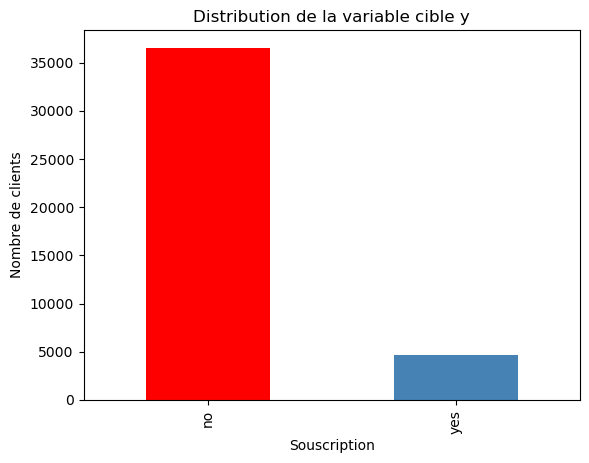

In [9]:
Cestia["y"].value_counts().plot(kind="bar", color=["red", "steelblue"])
plt.title("Distribution de la variable cible y")
plt.xlabel("Souscription")
plt.ylabel("Nombre de clients")
plt.show()

-  **no** est 7,9 fois plus fréquent que **yes**
- Le dataset est donc **déséquilibré**. Cela veut dire que l'accuracy seule peut être trompeuse.
- Pour comparer les modèles, nous regarderons surtout la **PR-AUC**.
- Pour le choix du seuil, nous regarderons ensuite la **précision**, le **rappel** et le **F1-score**.
- Enfin, pour la valeur métier, nous regarderons le **Lift@20%** et le **Recall@20%**.

**2.7. Vérifions l'existence des valeurs aberrantes dans le jeu de données**

**Statistique descriptive**

In [10]:
Cestia.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**ÂGE**

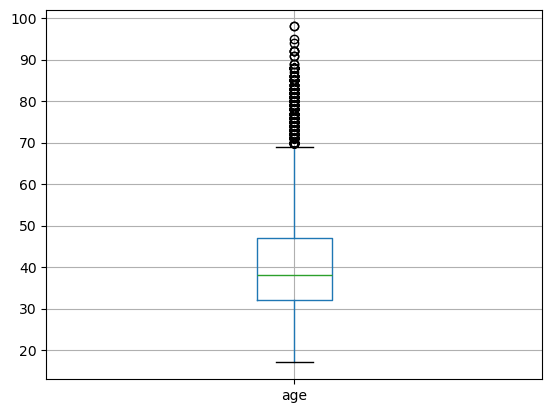

In [11]:
Cestia.boxplot(column="age")
plt.show()

- **ÂGE**:
    - l'âge minimum d'un client est **17** et l'âge maximum est **98** 
    - la majorité des clients ont entre **32** et **47 ans**
    - **la Variable Âge a 469 valeurs aberrantes**

**DURATION**

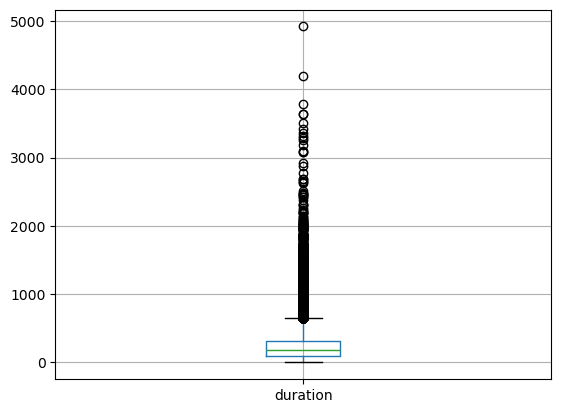

In [12]:
Cestia.boxplot(column="duration")
plt.show()

- **DURATION**:
    - 75% des appels durent moins de **319 secondes**
    - mais un appel peut durer **4918**
    - **On devra supprimer la variable duration car elle est connue qu'après un appel**

**CAMPAIGN**

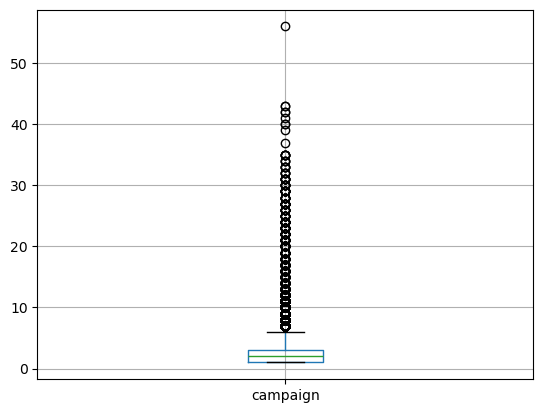

In [13]:
Cestia.boxplot(column="campaign")
plt.show()

- **campaign**:
    - la plupart des clients sont contactés **1** à **3 fois**
    - mais certains **56 fois**
    - **56 est une valeur aberrante**

**PDAYS**

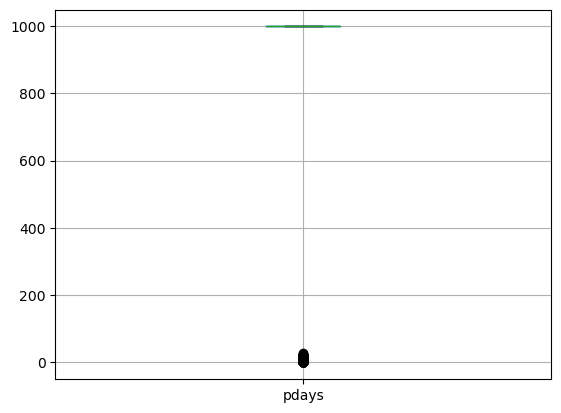

In [14]:
Cestia.boxplot(column="pdays")
plt.show()

- pdays = 999 : signifie "jamais contacté avant" . Ce n'est pas une vraie valeur numérique
- 39673 clients ont cette valeur. À traiter comme catégorie ou indicateur binaire

**2.8- Coorelation des variables explicatives avec la variable cible**

In [15]:
Cestia["y_numerique"] = (Cestia["y"] == "yes").astype(int)

colonnes numerique

In [23]:
colonnes_numerique = [
    col for col in Cestia.select_dtypes(include=["int64", "float64"]).columns
    if col != "y_numerique"
]
colonnes_numerique

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

**Correlation avec la variable cible**

In [24]:
correlation = Cestia[colonnes_numerique + ["y_numerique"]].corr()["y_numerique"].drop("y_numerique")
correlation

age               0.030399
duration          0.405274
campaign         -0.066357
pdays            -0.324914
previous          0.230181
emp.var.rate     -0.298334
cons.price.idx   -0.136211
cons.conf.idx     0.054878
euribor3m        -0.307771
nr.employed      -0.354678
Name: y_numerique, dtype: float64

**Taux de souscription par mois**

month
apr    20.478723
aug    10.602137
dec    48.901099
jul     9.046557
jun    10.511470
mar    50.549451
may     6.434745
nov    10.143867
oct    43.871866
sep    44.912281
Name: y_numerique, dtype: float64


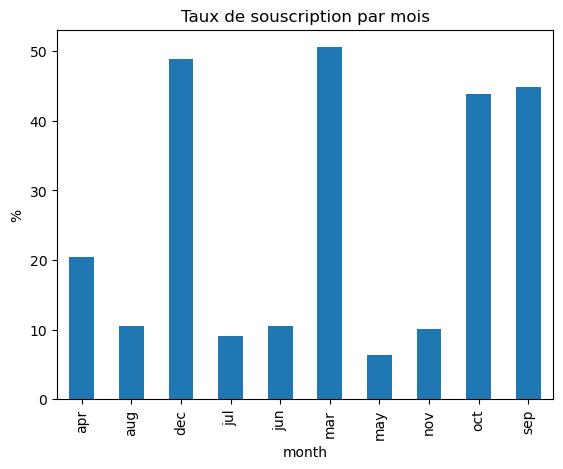

In [18]:
taux_mois = Cestia.groupby("month")["y_numerique"].mean()
print(taux_mois * 100)

(taux_mois * 100).plot(kind="bar")
plt.title("Taux de souscription par mois")
plt.ylabel("%")
plt.show()

**Taux de souscription par metier**

job
admin.           12.972558
blue-collar       6.894316
entrepreneur      8.516484
housemaid        10.000000
management       11.217510
retired          25.232558
self-employed    10.485574
services          8.138070
student          31.428571
technician       10.826042
unemployed       14.201183
unknown          11.212121
Name: y_numerique, dtype: float64


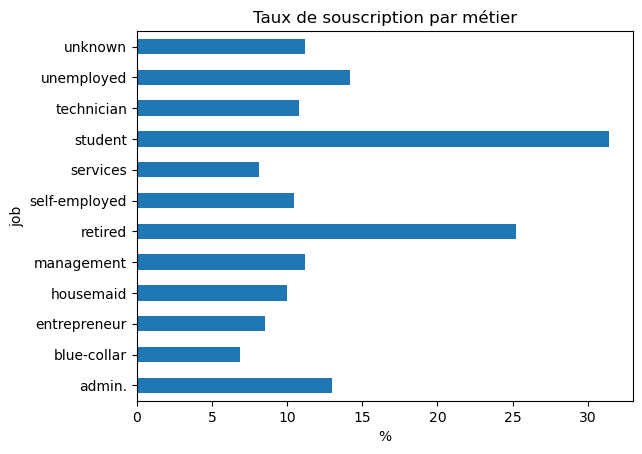

In [19]:
taux_metier = Cestia.groupby("job")["y_numerique"].mean()
print(taux_metier * 100)

(taux_metier * 100).plot(kind="barh")
plt.title("Taux de souscription par métier")
plt.xlabel("%")
plt.show()

**correlation avec la varible cible**

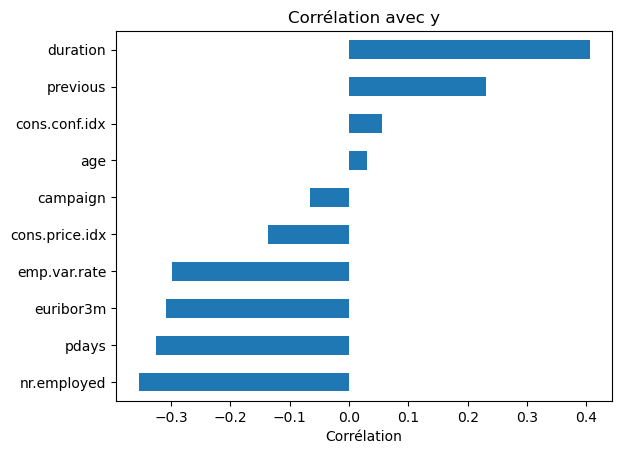

In [25]:
correlation.sort_values().plot(kind="barh")
plt.title("Corrélation avec y")
plt.xlabel("Corrélation")
plt.show()

**visualisation de la variable unknown**

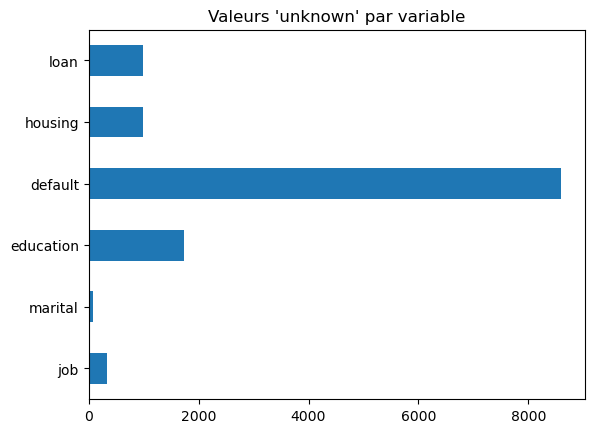

In [26]:
unknown = {}

for i in Cestia.select_dtypes(include=["object"]):
    n = (Cestia[i] == "unknown").sum()
    if n > 0:
        unknown[i] = n

pd.Series(unknown).plot(kind="barh")
plt.title("Valeurs 'unknown' par variable")
plt.show()

**Conclusion partielle:**
- Nous gardons 'unknown' comme catégorie à cause de **default** = 8597)
 
- Valeurs aberrantes :
     - Supprimer les 4 lignes avec duration = 0
     - Créer une variable binaire 'contacter_avant' pour transformer pdays en variable binaire 
- La variable cible étant déséquilibrée, on utilise F1-score pour un compromis entre précision et rappell, et PR-AUC pour la sélection du modèle.
 
- Variables importantes identifiées :
     - duration (*correlation = 0.41*)
     - nr.employed (*correlation = -0.36*)
     - euribor3m (*correlation = -0.31*)
     - *mars, décembre, septembre et octobre* ont un **taux > 40%**
     - taux de souscription par job : **student (31%), retired (25%)**

## ETAPE 3: PREPARATION DES DONNEES


**3.1 – Repartons du dataset brut**

In [27]:
Cestia_modele = Cestia.copy()
print("Taille initiale :", Cestia_modele.shape)

Taille initiale : (41188, 22)


**3.2 – Supprimons les doublons**

In [28]:
print("Lignes avant suppression des doublons :", Cestia_modele.shape[0])
Cestia_modele = Cestia_modele.drop_duplicates()
print("Lignes après suppression des doublons  :", Cestia_modele.shape[0])

Lignes avant suppression des doublons : 41188
Lignes après suppression des doublons  : 41176


**3.3 – Supprimons les variables qui posent problème pour une prédiction avant la campagne**

In [29]:
colonnes_a_supprimer = ["duration", "campaign"]
Cestia_modele = Cestia_modele.drop(columns=colonnes_a_supprimer)
print("Colonnes supprimées :", colonnes_a_supprimer)
print("Nouvelle taille :", Cestia_modele.shape)

Colonnes supprimées : ['duration', 'campaign']
Nouvelle taille : (41176, 20)


- **duration** est connue après l’appel, donc elle crée une fuite de données.
- **campaign** dépend de la campagne en cours, donc elle n’est pas cohérente avec notre objectif de prédiction avant l’action commerciale.

**3.4 – Transformons la variable pdays**

In [30]:
Cestia_modele["contacted_before"] = (Cestia_modele["pdays"] != 999).astype(int)
Cestia_modele["pdays_clean"] = Cestia_modele["pdays"].where(Cestia_modele["pdays"] < 999, 999)
Cestia_modele = Cestia_modele.drop(columns=["pdays"])

display(Cestia_modele[["contacted_before", "pdays_clean"]].head())
print(Cestia_modele["contacted_before"].value_counts())

,contacted_before,pdays_clean
0,0,999
1,0,999
2,0,999
3,0,999
4,0,999


contacted_before
0    39661
1     1515
Name: count, dtype: int64


- Ici, **999** signifie en réalité “jamais contacté auparavant”.
- On transforme donc **pdays** en deux informations plus lisibles :
    - **contacted_before** : le client a-t-il déjà été contacté ?
    - **pdays_clean** : nombre de jours si l’information existe.

**3.5 – Encodons la variable cible y**

In [31]:
Cestia_modele["y"] = (Cestia_modele["y"] == "yes").astype(int)

print("Répartition finale de la cible :")
print(Cestia_modele["y"].value_counts())
print()
print("Proportions :")
print(Cestia_modele["y"].value_counts(normalize=True).round(4))

Répartition finale de la cible :
y
0    36537
1     4639
Name: count, dtype: int64

Proportions :
y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


**3.6 – Regroupons les mois en saisons**

In [32]:
saison_temporelle = {
    "mar": "printemps", "apr": "printemps", "may": "printemps",
    "jun": "ete", "jul": "ete", "aug": "ete",
    "sep": "automne", "oct": "automne", "nov": "automne",
    "dec": "hiver", "jan": "hiver", "feb": "hiver"
}

Cestia_modele["saison"] = Cestia_modele["month"].map(saison_temporelle)
Cestia_modele["saison"].value_counts()

saison
ete          18663
printemps    16944
automne       5387
hiver          182
Name: count, dtype: int64

- Cette transformation simplifie la variable **month**.
- Elle permet de garder l’idée du moment de l’année, tout en réduisant le nombre de catégories.

**3.7 – Regroupons les niveaux d’éducation**

In [33]:
education_niveaux = {
    "illiterate": "bas",
    "basic.4y": "bas",
    "basic.6y": "bas",
    "basic.9y": "moyen",
    "high.school": "moyen",
    "professional.course": "moyen",
    "university.degree": "haut",
    "unknown": "unknown"
}

Cestia_modele["education_niveau"] = Cestia_modele["education"].map(education_niveaux)
Cestia_modele["education_niveau"].value_counts()

education_niveau
moyen      20797
haut       12164
bas         6485
unknown     1730
Name: count, dtype: int64

- Cela rend la variable plus simple à lire.
- Cela évite aussi d’avoir trop de petites modalités séparées.

**3.8 – Choisissons les variables finales**

In [34]:
colonnes_finales = [
    "age",
    "job",
    "marital",
    "education_niveau",
    "default",
    "housing",
    "loan",
    "contact",
    "saison",
    "day_of_week",
    "previous",
    "poutcome",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
    "contacted_before",
    "pdays_clean",
    "y",
]

Cestia_modele = Cestia_modele[colonnes_finales].copy()
print("Taille du dataset final de modélisation :", Cestia_modele.shape)
display(Cestia_modele.head())

Taille du dataset final de modélisation : (41176, 20)


,age,job,marital,education_niveau,default,housing,loan,contact,saison,day_of_week,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,contacted_before,pdays_clean,y
0,56,housemaid,married,bas,no,no,no,telephone,printemps,mon,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,999,0
1,57,services,married,moyen,unknown,no,no,telephone,printemps,mon,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,999,0
2,37,services,married,moyen,no,yes,no,telephone,printemps,mon,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,999,0
3,40,admin.,married,bas,no,no,no,telephone,printemps,mon,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,999,0
4,56,services,married,moyen,no,no,yes,telephone,printemps,mon,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,999,0


- Pour la version finale, on garde les variables utiles avant campagne.
- On remplace **month** par **saison** et **education** par **education_niveau** pour simplifier le jeu de données.

**3.9 – Séparons les données dans l’ordre du temps : train / validation / test**

In [35]:
n = len(Cestia_modele)
fin_train = int(0.70 * n)
fin_valid = int(0.85 * n)

train = Cestia_modele.iloc[:fin_train].copy()
valid = Cestia_modele.iloc[fin_train:fin_valid].copy()
test = Cestia_modele.iloc[fin_valid:].copy()

print("Train :", train.shape)
print("Validation :", valid.shape)
print("Test :", test.shape)

Train : (28823, 20)
Validation : (6176, 20)
Test : (6177, 20)


- Ici, on **ne mélange pas les lignes**.
- Le but est de respecter l’ordre temporel du dataset : on apprend sur le passé, puis on valide sur des observations plus récentes, et on garde le test pour la fin.

**3.10 – Séparons X et y**

In [36]:
X_train = train.drop(columns=["y"])
y_train = train["y"]

X_valid = valid.drop(columns=["y"])
y_valid = valid["y"]

X_test = test.drop(columns=["y"])
y_test = test["y"]

print("Taille X_train :", X_train.shape)
print("Taille X_valid :", X_valid.shape)
print("Taille X_test  :", X_test.shape)

Taille X_train : (28823, 19)
Taille X_valid : (6176, 19)
Taille X_test  : (6177, 19)


**3.11 – Définissons les colonnes numériques et catégorielles**

In [37]:
colonnes_numeriques = [
    "age",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
    "contacted_before",
    "pdays_clean",
]

colonnes_categorielles = [
    "job",
    "marital",
    "education_niveau",
    "default",
    "housing",
    "loan",
    "contact",
    "saison",
    "day_of_week",
    "poutcome",
]

print("Nombre de variables numériques :", len(colonnes_numeriques))
print("Nombre de variables catégorielles :", len(colonnes_categorielles))

Nombre de variables numériques : 9
Nombre de variables catégorielles : 10


## ETAPE 4: ENTRAINER LES MODELES

Dans cette partie, nous allons parlerons des modèles choisis et nous les comparerons.




### Les modèles choisis
Les modèles retenus pour notre études sont les suivants: 
- La **regression logistique** 
- **Random Forest**
- **XGBOOST**

Le choix de ces trois algorithmes permet de couvrir le large spectre de la modélisation statistique.

Étant face à un problème de **classification binaire**, l'idée est de commencer avec une **approche linéaire**(**regression logistique**) pour sa simplicité et son interprétabilité. 

Par la suite, nous évaluerons les approches par **agrégration parallèle**(**Random forest**) et par **optimisation séquentielle**(**XGBOOST**); 

L'approche par agrégation parallèle ayant pour particularité d'être stable et robuste face au bruit, et celle par optimisation séquentielle la particularité d'être performante avec des données tabulaires.

### 4.1 – Régression logistique

**Définition :**  
La régression logistique est un modèle linéaire de classification. 
Elle ne prédit pas directement une classe **no** ou **yes**, mais la probabilité qu'un événement appartienne à la classe **yes**.

Elle se fait en deux étapes:
- **étape 1 : le score linéaire ($z$) .** On calcule d'abord une somme pondérée des variables:  $$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

où $x_1, x_2, ...$ sont les données d'entrée (*features*) et $\beta_0$ est la valeur moyenne estimée de la variable $z$ lorsque les variables explicatives sont nulles; $\beta_1, \beta_2, ...$ sont les poids.


- **étape 2 : La fonction Sigmoïde $\sigma$.** 
On transforme  ce score $z$ en une probabilité entre 0 et 1 grâce à la fonction logistique : 
$$\sigma(z) = \frac{1}{1 + e^{-z}} = P(y=1)$$

$y$ étant la valeur de la cible **0** pour **non/no** et **1** pour **oui/yes**.


**Comment elle est appliquée dans notre cas?** 

Nous allons faire la regréssion logistique de deux façons:

**- Régression logistique avec classes équilibrées**


Ici, les variables numériques sont d'abord standardisées.
Ensuite, les variables catégorielles sont encodées en One Hot Encoding. 

Enfin, on cherche les meilleurs hyperparamètres `C` et `penalty`.

**Hyperparamètres testés :**
- `C`: C'est l'inverse de la force de régularisation. Elle mésure la pénalité appliquée aux poids des variables. Plus `C` est petit, plus la régularisation est forte.


- `penalty`(l1, l2): c'est le type de régularisation appliqué au modèle. Elle définit comment on punit la complexité pour éviter le surapprentissage. 

Quand on choisit l1(Lasso), on demande au modèle d'essayer de trouver les variables les plus importantes et d'ignorer les autres en mettant leur poids à zéro.

Quand on choisit l2(Ridge), on demande au modèle de garder tous les coefficients mais de ne laisser aucun d'entre eux prendre plus d'importance.
- `solver` : `saga`, c'est un paramètre qui permet au modèle de basculer librement entre les deux types de régularisation l1 et l2.


- `class_weight` : `balanced`, c'est un paramètre qui permet de gérer le déséquilibre de la variable cible y. Concrètement, nous disons au modèle que faire une erreur sur un "yes" coûte beaucoup plus cher que de se tromper sur un "no".

**- Régression logistique avec SMOTE**  

SMOTE est une méthode qui crée artificiellement de nouveaux exemples de la classe minoritaire.

SMOTE ne se contente pas de dupliquer les lignes existantes. Elle crée de nouveaux exemples synthétiques pour la classe minoritaire.

D'abord, elle choisit un point de la classe minoritaire. Ensuite, elle identifie ses k plus proches voisins. Enfin, elle crée un nouveau point n'importe où sur la ligne imaginaire qui relie le point initial à l'un de ses voisins.
 


**Hyperparamètres testés :**
- `smote__k_neighbors` : les k plus proches voisins.
- `modele__C` ou `C` 
- `modele__penalty` : `["l1", "l2"]`
- `solver` : `saga`

### 4.2 – Random Forest

**Définition :**  
Mathématiquement, le Random Forest est une **agrégration** de plusieurs fonctions simples (arbres de décision).

- **Arbres de décision $h(x)$ :**
C'est une fonction qui sépare l'espace des données en "boîtes0" rectangulaires par des conditions logiques.

- **La forêt $H(x)$ :**
Si on a  $T$ arbres, la prédiction finale $\hat{y}$, est le **vote majoritaire** de tous les arbres:

$$\hat{y} = \text{mode}\{h_1(x), h_2(x), ..., h_T(x)\} = H(x)$$


**Comment il est appliqué dans notre cas?**  
D'abord, on encode les variables catégorielles. Les variables numériques restent telles quelles. Enfin, on teste plusieurs profondeurs et tailles de forêt.

**Hyperparamètres testés :**
- `n_estimators` : le nombre d'arbres dans la forêt. Plus il y a d'arbres, plus le modèle est robuste. Cependant, au-delà d'un certain nombre, la performance stagne et le temps de calcul augmente.


- `max_depth` : la profondeur maximale de chaque arbre. Un arbre trop profond va apprendre les détails.


- `min_samples_split` : c'est le nombre minimal d'individus requis pour créer une nouvelle branche.


- `min_samples_leaf` : c'est le nombre minimal d'individus pour constituer une feuille finale.


- `max_features` : c'est le nombre de variables tirées au sort à chaque étape de construction de l'arbre.


- `class_weight` : `balanced`

### 4.3 – XGBoost (si disponible)

**Définition :**  
XGBoost, eXtreme Gradient Boosting est une bibliothèque de machine learning qui utilise les arbres de décision auxquels est appliqué le *boosting* de gradient.

Le *boosting* de gradient est une méthode qui est utilisée pour réduire le nombre d'erreurs dans l'analyse prédictive des données.

XGBoost est donc un assemblage d'arbres décisionnels qui prédisent les résidus, et corrige les erreurs des arbres décisionnels précédents.


*Le résidu représente l'erreur entre la valeur réelle et la valeur prédite.*


**Comment il est appliqué dans notre cas ?**  

On commence également par l'encodage des variables catégorielles.

Puis on calcule le ratio entre la classe négative et positive pour aider le modèle avec `scale_pos_weight`

Enfin, on teste plusieurs profondeurs, nombres d'arbres et taux d'apprentissage.



**Hyperparamètres testés :**
- `n_estimators`
- `max_depth`
- `learning_rate` : c'est le "pas" d'apprentissage. C'est-à-dire à quel point on prend compte des corrections apportées par le nouvel arbre.

- `subsample` : c'est la fraction de lignes(individus), utilisée pour chaque arbre.

- `colsample_bytree` : c'est la fraction de colonnes(variables), utilisée par chaque arbre.

`scale_pos_weight` : permet de mésurer le poids accordé à la classe positive.

**4.4 – Construisons les préprocesseurs**

In [43]:
try:
    encodeur = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encodeur = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocesseur_avec_scaler = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colonnes_numeriques),
        ("cat", encodeur, colonnes_categorielles),
    ]
)

preprocesseur_sans_scaler = ColumnTransformer(
    transformers=[
        ("num", "passthrough", colonnes_numeriques),
        ("cat", encodeur, colonnes_categorielles),
    ]
)

print("Préprocesseurs créés.")

Préprocesseurs créés.


**4.5 – Calculons le ratio de déséquilibre sur le train**

In [44]:
nb_non = (y_train == 0).sum()
nb_oui = (y_train == 1).sum()
ratio_positif = nb_non / nb_oui

print("Nombre de no sur le train :", nb_non)
print("Nombre de yes sur le train :", nb_oui)
print("Ratio no/yes :", round(ratio_positif, 2))

Nombre de no sur le train : 27216
Nombre de yes sur le train : 1607
Ratio no/yes : 16.94


**4.6 – Construisons les pipelines des modèles**

In [45]:
pipeline_logistique = Pipeline(
    steps=[
        ("preparation", preprocesseur_avec_scaler),
        ("modele", LogisticRegression(
            max_iter=3000,
            solver="saga",
            class_weight="balanced",
            random_state=42,
        )),
    ]
)

pipeline_logistique_smote = PipelineImb(
    steps=[
        ("preparation", preprocesseur_avec_scaler),
        ("smote", SMOTE(random_state=42)),
        ("modele", LogisticRegression(
            max_iter=3000,
            solver="saga",
            random_state=42,
        )),
    ]
)

pipeline_rf = Pipeline(
    steps=[
        ("preparation", preprocesseur_sans_scaler),
        ("modele", RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

modeles = {
    "logistique_class_weight": {
        "pipeline": pipeline_logistique,
        "parametres": {
            "modele__C": [0.001, 0.01, 0.1, 1, 10],
            "modele__penalty": ["l1", "l2"],
        },
        "type_recherche": "grid",
    },
    "logistique_smote": {
        "pipeline": pipeline_logistique_smote,
        "parametres": {
            "smote__k_neighbors": [3, 5, 7],
            "modele__C": [0.01, 0.1, 1],
            "modele__penalty": ["l1", "l2"],
        },
        "type_recherche": "grid",
    },
    "random_forest": {
        "pipeline": pipeline_rf,
        "parametres": {
            "modele__n_estimators": [200, 400],
            "modele__max_depth": [5, 10, 20, None],
            "modele__min_samples_split": [2, 5, 10],
            "modele__min_samples_leaf": [1, 2, 5],
            "modele__max_features": ["sqrt", 0.5],
        },
        "type_recherche": "random",
        "n_iter": 12,
    },
}

if xgboost_disponible:
    pipeline_xgb = Pipeline(
        steps=[
            ("preparation", preprocesseur_sans_scaler),
            ("modele", XGBClassifier(
                eval_metric="logloss",
                random_state=42,
                scale_pos_weight=ratio_positif,
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
            )),
        ]
    )

    modeles["xgboost"] = {
        "pipeline": pipeline_xgb,
        "parametres": {
            "modele__n_estimators": [100, 200],
            "modele__max_depth": [3, 5, 7],
            "modele__learning_rate": [0.03, 0.1],
            "modele__subsample": [0.8, 1.0],
            "modele__colsample_bytree": [0.8, 1.0],
        },
        "type_recherche": "random",
        "n_iter": 10,
    }

print("Modèles construits :", list(modeles.keys()))

Modèles construits : ['logistique_class_weight', 'logistique_smote', 'random_forest', 'xgboost']


**4.7 – Récapitulatif des espaces d’hyperparamètres**

In [46]:
lignes_hyper = []

for nom_modele, infos in modeles.items():
    for nom_param, valeurs in infos["parametres"].items():
        lignes_hyper.append({
            "modele": nom_modele,
            "hyperparametre": nom_param,
            "valeurs_testees": str(valeurs),
        })

tableau_hyper = pd.DataFrame(lignes_hyper)
display(tableau_hyper)

,modele,hyperparametre,valeurs_testees
0,logistique_class_weight,modele__C,"[0.001, 0.01, 0.1, 1, 10]"
1,logistique_class_weight,modele__penalty,"['l1', 'l2']"
2,logistique_smote,smote__k_neighbors,"[3, 5, 7]"
3,logistique_smote,modele__C,"[0.01, 0.1, 1]"
4,logistique_smote,modele__penalty,"['l1', 'l2']"
5,random_forest,modele__n_estimators,"[200, 400]"
6,random_forest,modele__max_depth,"[5, 10, 20, None]"
7,random_forest,modele__min_samples_split,"[2, 5, 10]"
8,random_forest,modele__min_samples_leaf,"[1, 2, 5]"
9,random_forest,modele__max_features,"['sqrt', 0.5]"


**4.8 – Optimisons les hyperparamètres sur le jeu d’entraînement**

In [47]:
tscv = TimeSeriesSplit(n_splits=3)

resultats_tuning = []
objets_recherche = {}

for nom_modele, infos in modeles.items():
    print("=" * 70)
    print("Optimisation du modèle :", nom_modele)

    debut = time.time()

    if infos["type_recherche"] == "grid":
        recherche = GridSearchCV(
            estimator=infos["pipeline"],
            param_grid=infos["parametres"],
            scoring="average_precision",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        )
    else:
        recherche = RandomizedSearchCV(
            estimator=infos["pipeline"],
            param_distributions=infos["parametres"],
            n_iter=infos["n_iter"],
            scoring="average_precision",
            cv=tscv,
            n_jobs=-1,
            refit=True,
            random_state=42,
        )

    recherche.fit(X_train, y_train)
    duree = time.time() - debut

    objets_recherche[nom_modele] = recherche

    resultats_tuning.append({
        "modele": nom_modele,
        "methode_recherche": infos["type_recherche"],
        "pr_auc_cv_train": recherche.best_score_,
        "meilleurs_parametres": recherche.best_params_,
        "duree_secondes": round(duree, 2),
    })

    print("Meilleur score CV (PR-AUC) :", round(recherche.best_score_, 4))
    print("Meilleurs paramètres :", recherche.best_params_)
    print("Durée (s) :", round(duree, 2))

tableau_tuning = pd.DataFrame(resultats_tuning).sort_values(
    by="pr_auc_cv_train",
    ascending=False
).reset_index(drop=True)

display(tableau_tuning)

Optimisation du modèle : logistique_class_weight
Meilleur score CV (PR-AUC) : 0.0926
Meilleurs paramètres : {'modele__C': 1, 'modele__penalty': 'l1'}
Durée (s) : 925.07
Optimisation du modèle : logistique_smote
Meilleur score CV (PR-AUC) : 0.0624
Meilleurs paramètres : {'modele__C': 0.01, 'modele__penalty': 'l2', 'smote__k_neighbors': 7}
Durée (s) : 100.94
Optimisation du modèle : random_forest
Meilleur score CV (PR-AUC) : 0.0664
Meilleurs paramètres : {'modele__n_estimators': 200, 'modele__min_samples_split': 2, 'modele__min_samples_leaf': 2, 'modele__max_features': 0.5, 'modele__max_depth': None}
Durée (s) : 86.27
Optimisation du modèle : xgboost
Meilleur score CV (PR-AUC) : 0.0712
Meilleurs paramètres : {'modele__subsample': 1.0, 'modele__n_estimators': 100, 'modele__max_depth': 3, 'modele__learning_rate': 0.03, 'modele__colsample_bytree': 1.0}
Durée (s) : 9.13


,modele,methode_recherche,pr_auc_cv_train,meilleurs_parametres,duree_secondes
0,logistique_class_weight,grid,0.092604,"{'modele__C': 1, 'modele__penalty': 'l1'}",925.07
1,xgboost,random,0.071150,"{'modele__subsample': 1.0, 'modele__n_estimato...",9.13
2,random_forest,random,0.066448,"{'modele__n_estimators': 200, 'modele__min_sam...",86.27
3,logistique_smote,grid,0.062444,"{'modele__C': 0.01, 'modele__penalty': 'l2', '...",100.94


- Ici, on choisit les meilleurs hyperparamètres uniquement sur le **train**. 
- La métrique de comparaison pendant cette phase est la **PR-AUC** (`average_precision`), car notre jeu de données est déséquilibré.

**4.9 – Mettons maintenant les modèles en compétition sur le jeu de validation**

In [48]:
resultats_validation = []

for nom_modele, recherche in objets_recherche.items():
    meilleur_modele = recherche.best_estimator_

    y_proba_valid = meilleur_modele.predict_proba(X_valid)[:, 1]
    y_pred_valid_05 = (y_proba_valid >= 0.50).astype(int)

    pr_auc_valid = average_precision_score(y_valid, y_proba_valid)
    roc_auc_valid = roc_auc_score(y_valid, y_proba_valid)
    precision_valid = precision_score(y_valid, y_pred_valid_05, zero_division=0)
    recall_valid = recall_score(y_valid, y_pred_valid_05, zero_division=0)
    f1_valid = f1_score(y_valid, y_pred_valid_05, zero_division=0)

    resultat_top = pd.DataFrame({"y": y_valid.values, "proba": y_proba_valid})
    resultat_top = resultat_top.sort_values(by="proba", ascending=False)

    n_top = math.ceil(len(resultat_top) * 0.20)
    top20 = resultat_top.iloc[:n_top]

    taux_base = resultat_top["y"].mean()
    taux_top20 = top20["y"].mean()
    lift_top_20 = taux_top20 / taux_base if taux_base > 0 else 0

    total_positifs = resultat_top["y"].sum()
    positifs_top20 = top20["y"].sum()
    recall_top_20 = positifs_top20 / total_positifs if total_positifs > 0 else 0

    resultats_validation.append({
        "modele": nom_modele,
        "pr_auc_validation": pr_auc_valid,
        "roc_auc_validation": roc_auc_valid,
        "precision_validation_0_5": precision_valid,
        "recall_validation_0_5": recall_valid,
        "f1_validation_0_5": f1_valid,
        "lift_top_20_validation": lift_top_20,
        "recall_top_20_validation": recall_top_20,
        "meilleurs_parametres": recherche.best_params_,
    })

tableau_validation = pd.DataFrame(resultats_validation).sort_values(
    by="pr_auc_validation",
    ascending=False
).reset_index(drop=True)

display(tableau_validation)

,modele,pr_auc_validation,roc_auc_validation,precision_validation_0_5,recall_validation_0_5,f1_validation_0_5,lift_top_20_validation,recall_top_20_validation,meilleurs_parametres
0,random_forest,0.158536,0.583200,0.264368,0.070015,0.110710,1.346160,0.269406,"{'modele__n_estimators': 200, 'modele__min_sam..."
1,logistique_class_weight,0.148373,0.567402,0.098516,0.888889,0.177373,1.597139,0.319635,"{'modele__C': 1, 'modele__penalty': 'l1'}"
2,logistique_smote,0.143886,0.596358,0.107448,0.996956,0.193988,1.445031,0.289193,"{'modele__C': 0.01, 'modele__penalty': 'l2', '..."
3,xgboost,0.121577,0.546709,0.107044,0.996956,0.193329,1.003916,0.200913,"{'modele__subsample': 1.0, 'modele__n_estimato..."


Le **meilleur modèle** selon la métrique **PR-AUC** est celui de **random forest**.
  

**4.10 – Identifions le modèle champion**

In [49]:
modele_champion_nom = tableau_validation.loc[0, "modele"]
modele_champion_train = objets_recherche[modele_champion_nom].best_estimator_

print("Le modèle champion à ce stade est :", modele_champion_nom)
print("Ses meilleurs hyperparamètres sont :")
print(objets_recherche[modele_champion_nom].best_params_)

Le modèle champion à ce stade est : random_forest
Ses meilleurs hyperparamètres sont :
{'modele__n_estimators': 200, 'modele__min_samples_split': 2, 'modele__min_samples_leaf': 2, 'modele__max_features': 0.5, 'modele__max_depth': None}


Le **modèle champion** est : **random forest**.
Il a été retenu car il obtient la meilleure **PR-AUC** sur le jeu de validation. Or, dans ce projet, la PR-AUC est la métrique principale de sélection car la classe positive est minoritaire et cette métrique est plus adaptée que les mesures calculées à un seuil fixe. Bien que la régression logistique présente un rappel plus élevé au seuil de 0.5, elle reste moins performante globalement sur la courbe précision-rappel. Le Random Forest est donc le meilleur compromis pour la phase de sélection du modèle.


Si le critère de selection était **Lift@20%** ou **Recall@20%**, alors la **regression logistique** aurait été retenue.

## ETAPE 5: EVALUER LE MODELE

Nous avons choisi le meilleur algorithme. Il faut maintenant :
1. choisir un **seuil de décision** sur la validation ;
2. réentraîner le champion sur **train + validation** ;
3. évaluer une seule fois sur le **test** final.

**5.1 – Choisissons le seuil de décision sur la validation**

In [50]:
y_proba_valid_champion = modele_champion_train.predict_proba(X_valid)[:, 1]

precisions, rappels, seuils = precision_recall_curve(y_valid, y_proba_valid_champion)

precisions = precisions[:-1]
rappels = rappels[:-1]

f1_scores = np.where(
    (precisions + rappels) == 0,
    0,
    2 * precisions * rappels / (precisions + rappels)
)

meilleur_idx = np.argmax(f1_scores)
seuil_retenu = seuils[meilleur_idx]

tableau_seuils = pd.DataFrame({
    "seuil": seuils,
    "precision": precisions,
    "recall": rappels,
    "f1": f1_scores,
}).sort_values(by="f1", ascending=False)

print("Seuil retenu :", round(seuil_retenu, 4))
display(tableau_seuils.head(10))

Seuil retenu : 0.2232


,seuil,precision,recall,f1
2960,0.223218,0.134921,0.569254,0.218139
2959,0.223176,0.134872,0.569254,0.218076
2958,0.223135,0.134823,0.569254,0.218012
2957,0.222867,0.134775,0.569254,0.217949
2949,0.222569,0.134553,0.570776,0.217770
2963,0.223308,0.134706,0.567732,0.217747
2948,0.222556,0.134505,0.570776,0.217707
2962,0.223284,0.134657,0.567732,0.217683
2947,0.222531,0.134457,0.570776,0.217644
2956,0.222849,0.134532,0.569254,0.217632


Le seuil retenu pour le **F1-score** **0.2232**.


**5.2 – Réentraînons le modèle champion sur train + validation**

In [51]:
X_train_valid = pd.concat([X_train, X_valid], axis=0)
y_train_valid = pd.concat([y_train, y_valid], axis=0)

modele_final = clone(modeles[modele_champion_nom]["pipeline"])
modele_final.set_params(**objets_recherche[modele_champion_nom].best_params_)
modele_final.fit(X_train_valid, y_train_valid)

print("Le modèle final a été réentraîné sur train + validation.")

Le modèle final a été réentraîné sur train + validation.


**5.3 – Évaluons le modèle final sur le test**

In [56]:
y_proba_test = modele_final.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= seuil_retenu).astype(int)

pr_auc_test = average_precision_score(y_test, y_proba_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
precision_test = precision_score(y_test, y_pred_test, zero_division=0)
recall_test = recall_score(y_test, y_pred_test, zero_division=0)
f1_test = f1_score(y_test, y_pred_test, zero_division=0)
matrice_conf = confusion_matrix(y_test, y_pred_test)

resultat_top_test = pd.DataFrame({"y": y_test.values, "proba": y_proba_test})
resultat_top_test = resultat_top_test.sort_values(by="proba", ascending=False)

n_top_test = math.ceil(len(resultat_top_test) * 0.20)
top20_test = resultat_top_test.iloc[:n_top_test]

taux_base_test = resultat_top_test["y"].mean()
taux_top20_test = top20_test["y"].mean()
lift_top_20_test = taux_top20_test / taux_base_test if taux_base_test > 0 else 0

total_positifs_test = resultat_top_test["y"].sum()
positifs_top20_test = top20_test["y"].sum()
recall_top_20_test = positifs_top20_test / total_positifs_test if total_positifs_test > 0 else 0

tableau_test = pd.DataFrame([{
    "modele_retenu": modele_champion_nom,
    "seuil_retenu": seuil_retenu,
    "pr_auc_test": pr_auc_test,
    "roc_auc_test": roc_auc_test,
    "precision_test": precision_test,
    "recall_test": recall_test,
    "f1_test": f1_test,
    "lift_top_20_test": lift_top_20_test,
    "recall_top_20_test": recall_top_20_test,
}])

display(tableau_test)

,modele_retenu,seuil_retenu,pr_auc_test,roc_auc_test,precision_test,recall_test,f1_test,lift_top_20_test,recall_top_20_test
0,random_forest,0.223218,0.492446,0.625496,0.486601,0.481684,0.48413,1.367757,0.273684


**5.4 – Affichons la matrice de confusion**

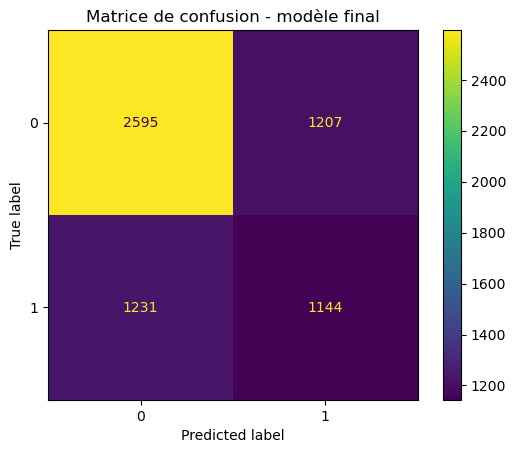

In [57]:
disp = ConfusionMatrixDisplay(confusion_matrix=matrice_conf)
disp.plot()
plt.title("Matrice de confusion - modèle final")
plt.show()

**5.5 – Conclusion**

In [58]:
print("MODÈLE FINAL RETENU :", modele_champion_nom)
print("MEILLEURS HYPERPARAMÈTRES :", objets_recherche[modele_champion_nom].best_params_)
print("SEUIL FINAL RETENU :", round(seuil_retenu, 4))
print()
print("PR-AUC test :", round(pr_auc_test, 4))
print("ROC-AUC test :", round(roc_auc_test, 4))
print("Precision test :", round(precision_test, 4))
print("Recall test :", round(recall_test, 4))
print("F1 test :", round(f1_test, 4))
print("Lift@20% test :", round(lift_top_20_test, 4))
print("Recall@20% test :", round(recall_top_20_test, 4))

MODÈLE FINAL RETENU : random_forest
MEILLEURS HYPERPARAMÈTRES : {'modele__n_estimators': 200, 'modele__min_samples_split': 2, 'modele__min_samples_leaf': 2, 'modele__max_features': 0.5, 'modele__max_depth': None}
SEUIL FINAL RETENU : 0.2232

PR-AUC test : 0.4924
ROC-AUC test : 0.6255
Precision test : 0.4866
Recall test : 0.4817
F1 test : 0.4841
Lift@20% test : 1.3678
Recall@20% test : 0.2737


### Conclusion finale

Le modèle final retenu est celui de la **forêt aléatoire** ou **random forest**.
Nous avons opté pour une approche équilibrée dans ce projet c'est-à-dire que l'objectif n'est pas seulement de maximiser le **nombre de clients détectés**, ni de **réduire les faux positifs** uniquement, mais de trouver un compromis raisonnable entre les deux.

Les résultats obtenus sur le jeu de test montrent ce compromis. 
En **précision** nous avons une valeur de **0.4866**; Cela signifie qu'environ **48.7%** souscrivent réellement.

En **recall**, nous avons une valeur de **0.4817**; Cela signifie que notre modèle retrouve environ **48.2%** de tous les clients qui auraient réellement souscrit.

Enfin au niveau du **F1-SCORE**, nous obtenons une valeur de **0.4841**. Cette valeur confirme que le modèle a un comportement assez équilibré entre **précision** et **rappel**. D'où le choix du modèle **random forest**.